# Oracle Agent Memory — OAMP vs Naive Memory, Benchmarked on Claude

[![Oracle AI Agent Memory](https://img.shields.io/badge/Oracle-AI%20Agent%20Memory-red?style=flat-square)](https://www.oracle.com/database/ai-agent-memory/) [![Model](https://img.shields.io/badge/Model-claude--opus--4--8-8A2BE2?style=flat-square)](https://www.anthropic.com/)

Every multi-turn agent needs **memory** — a way to carry facts from earlier turns into later ones. The simplest approach is to **re-send the entire conversation history** on every request ("naive memory"). It works, but the prompt grows without bound: more tokens, more cost, and eventually you overflow the context window.

**Oracle AI Agent Memory (OAMP)** is the alternative. It persists each turn into Oracle AI Database, extracts durable *memories*, and on each new turn retrieves a small, relevant **context card** instead of the whole transcript. The prompt stays small and flat.

This notebook **measures the trade-off** head-to-head, on Anthropic's **Claude Opus 4.8**, across four benchmarks:

| # | Benchmark | Question it answers |
|---|-----------|---------------------|
| 1 | **Token consumption** | How many input tokens does each pattern send per turn? |
| 2 | **Latency** | What does each memory pattern cost in wall-clock time? |
| 3 | **Response quality** | Does the smaller OAMP prompt hurt answers? (LLM-as-a-judge) |
| 4 | **A cache-friendly hybrid** | Can we get durable memory *and* prompt caching? What's the catch? |

> **The whole stack is Anthropic + open source.** Both agents and the judge run on **`claude-opus-4-8`**; OAMP's memory-extraction helper runs on **`claude-haiku-4-5`** (via LiteLLM); embeddings are generated locally with the open-source **`nomic-embed-text-v1.5`** model (Anthropic has no embeddings API). Vectors and memories live in **Oracle AI Database 26ai**.

## 1. Install dependencies

`oracleagentmemory` is the OAMP client. `anthropic` is the Claude SDK. `litellm` lets OAMP's internal extractor call Claude. `fastembed` runs the local embedding model. `matplotlib` / `numpy` draw the charts. (No `openai` — this notebook is Anthropic-only.)

In [1]:
%pip install --upgrade pip
%pip install --upgrade oracleagentmemory anthropic litellm fastembed matplotlib numpy

Note: you may need to restart the kernel to use updated packages.
  Using cached litellm-1.89.1-py3-none-any.whl.metadata (34 kB)
Note: you may need to restart the kernel to use updated packages.


## 2. Configure the Anthropic-only stack

We use **two model tiers**, but we place the boundary deliberately — **by whether the work sits on the recall-critical path**, not by whether it *feels* mechanical:

- **`claude-opus-4-8`** — the *high-quality* tier. It answers the user (in **both** agents), acts as the impartial judge, **and powers the live OAMP agent's inline memory extraction + summarisation**. Within a session the OAMP agent only ever sees the retrieved context card, so the card's recall quality is capped by extraction quality — a cheap, lossy extractor quietly drops facts the agent is later graded on. Here, extraction *is* the agent's memory, not a throwaway transform.
- **`claude-haiku-4-5`** — the *cheap* tier, reserved for work that runs **off the user's clock and off the recall path**: cache-friendly compaction and the offline batch-extraction job (Benchmark 4 / Strategy 6), where nobody is waiting and a small slip doesn't cost a graded answer.

> Set `ANTHROPIC_API_KEY` below (or in your environment). No OpenAI key is required anywhere in this notebook.

In [2]:
%matplotlib inline
import os
import warnings
import getpass

# OAMP wraps some async internals in sync methods; inside a notebook kernel that
# prints a harmless "async method in sync context" UserWarning. Silence the noise.
warnings.filterwarnings("ignore", message=".*asynchronous method.*")

# Anthropic is the ONLY LLM provider in this notebook. Set your key here or in the env.
os.environ["ANTHROPIC_API_KEY"] = getpass.getpass("Enter your Anthropic API key: ")
assert os.environ.get("ANTHROPIC_API_KEY"), "ANTHROPIC_API_KEY is not set."

# Two model tiers, split by whether the work sits on the recall-critical path:
AGENT_MODEL = "claude-opus-4-8"    # both agents, the judge, AND the live OAMP agent's inline extraction + summarisation
SMALL_MODEL = "claude-haiku-4-5"   # off-critical-path only: cache-friendly compaction + offline batch extraction (Strategy 6)

_key = os.environ.get("ANTHROPIC_API_KEY", "")
print("Anthropic key set:", bool(_key) and "YOUR_" not in _key)
print("Agent/judge model:", AGENT_MODEL, "| small model:", SMALL_MODEL)

Anthropic key set: True
Agent/judge model: claude-opus-4-8 | small model: claude-haiku-4-5


### A local embedder for OAMP

OAMP stores and searches **vectors**, so it needs an embedding model — and Anthropic doesn't offer one. We plug a local, open-source embedder into OAMP's `IEmbedder` interface. It downloads once and runs on CPU (ONNX), keeping the notebook key-light and fully reproducible.

In [3]:
import numpy as np
from fastembed import TextEmbedding
from oracleagentmemory.apis import IEmbedder


class FastEmbedEmbedder(IEmbedder):
    """A local, open-source embedder so the whole notebook stays Anthropic-only.

    Anthropic has no embeddings endpoint, so OAMP's vector search needs embeddings
    from elsewhere. We generate them locally with `nomic-embed-text-v1.5` (768-dim)
    via fastembed — ONNX on CPU, no API key, no GPU. OAMP calls `embed(texts, is_query=...)`;
    nomic uses different prefixes for documents vs queries, which fastembed's `.embed()`
    / `.query_embed()` handle for us. We L2-normalise so a dot product equals cosine.
    """

    def __init__(self, model_name: str = "nomic-ai/nomic-embed-text-v1.5"):
        self._model = TextEmbedding(model_name=model_name)

    def embed(self, texts, *, is_query: bool = False) -> np.ndarray:
        vectors = self._model.query_embed(texts) if is_query else self._model.embed(texts)
        arr = np.asarray(list(vectors), dtype=np.float32)
        norms = np.linalg.norm(arr, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        return arr / norms

    async def embed_async(self, texts, *, is_query: bool = False) -> np.ndarray:
        return self.embed(texts, is_query=is_query)


embedder = FastEmbedEmbedder()
print(f"Embedder ready — {embedder.embed(['dimension probe']).shape[1]} dimensions (nomic-embed-text-v1.5)")

/Users/richmondalake/opt/anaconda3/envs/oracle_demos/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Embedder ready — 768 dimensions (nomic-embed-text-v1.5)


## 3. Connect to Oracle and create an OAMP client

We open a connection to Oracle AI Database and build an `OracleAgentMemory` client. Attaching an `Llm` turns on **automatic memory extraction**: after each exchange OAMP asks the attached model to distil durable facts ("the cohort has 3,412 trios"; "Dr. Sarah Chen runs the Hi-C arm") and stores them as searchable memories. Because those memories *are* the live agent's entire recall surface, we attach the **capable** model (`claude-opus-4-8`) here — the cheap tier under-extracts specific sub-facts (a platform name, a read depth) that a recall probe will later ask for. The cadence is tuned for frequent updates so the retrieved context card stays fresh.

> We pass `table_name_prefix="oamp_bench"` so this benchmark's tables stay isolated from any other demos sharing the `VECTOR` schema, and `schema_policy="recreate"` so **every execution starts from an empty memory store** — no facts leak in from a previous run to inflate recall.

In [4]:
import oracledb
from oracleagentmemory.core import OracleAgentMemory
from oracleagentmemory.core.llms import Llm
from oracleagentmemory.apis.thread import Message

os.environ.setdefault("DB_USER", "VECTOR")
os.environ.setdefault("DB_PASSWORD", "VectorPwd_2025")
os.environ.setdefault("DB_CONNECT_STRING", "localhost:1521/FREEPDB1")

connection = oracledb.connect(
    user=os.environ["DB_USER"],
    password=os.environ["DB_PASSWORD"],
    dsn=os.environ["DB_CONNECT_STRING"],
)

# OAMP attaches an LLM that automatically extracts durable memories AND maintains the
# rolling context summary. Within a single session the retrieved context card is the
# ONLY thing the OAMP agent sees, so its recall quality is bounded by how well this
# helper extracts — a lossy extractor silently drops facts the agent is later asked
# about. So we route it to the capable model (Opus) via LiteLLM's `anthropic/` provider.
# (Off-critical-path work -- compaction, offline batch -- keeps the cheap tier; see Benchmark 4.)
extractor_llm = Llm("anthropic/" + AGENT_MODEL)

client = OracleAgentMemory(
    connection=connection,
    embedder=embedder,
    llm=extractor_llm,
    extract_memories=True,
    schema_policy="recreate",                # PRISTINE RUN: drop & recreate the oamp_bench tables on every execution
    table_name_prefix="oamp_bench",          # isolate this benchmark's tables from other demos in the schema
)

USER_ID = "benchmark-user"
AGENT_ID = "benchmark-agent"

for create_fn, eid, info in [
    (client.add_user, USER_ID, "Richmond - benchmarking OAMP vs naive memory."),
    (client.add_agent, AGENT_ID, "OAMP-backed research assistant for benchmarks."),
]:
    try:
        create_fn(eid, info)
    except ValueError as exc:
        if "already exists" not in str(exc):
            raise

thread = client.create_thread(
    user_id=USER_ID,
    agent_id=AGENT_ID,
    enable_context_summary=True,         # keep a rolling summary of the thread
    context_summary_update_frequency=2,  # refresh it every 2 turns
    memory_extraction_frequency=2,       # extract durable memories every 2 turns
    memory_extraction_window=4,          # over a sliding window of the last 4 messages
)
print(f"OAMP thread created: {thread.thread_id}")
print("Pristine run: schema_policy='recreate' dropped & rebuilt the oamp_bench tables, so no memories leak in from a prior run.")

OAMP thread created: 3e807801-d56a-44fe-b26e-044a7fd9b810
Pristine run: schema_policy='recreate' dropped & rebuilt the oamp_bench tables, so no memories leak in from a prior run.


## 4. Define both agents, instrumented

Both agents answer with the **same model and the same system prompt** — the *only* difference is **how they remember**:

- **Naive agent** keeps an append-only `messages` list and re-sends the **entire history** every turn.
- **OAMP agent** sends only the **system prompt + a retrieved context card + the new question**.

We capture four streams of data per turn so we can compare them:

1. **Input tokens** — real Anthropic `usage` (uncached + cache-write + cache-read).
2. **Cache reads** — input tokens served from Anthropic's **prompt cache**.
3. **Memory-layer latency** — time spent in the memory layer before the model call.
4. **End-to-end latency** — total wall-clock time for the turn.

> **Anthropic prompt caching is explicit.** We mark the conversation prefix with `cache_control`; Anthropic then re-reads the unchanged prefix at ~0.1× cost with near-zero prefill latency. Because it's opt-in, we can *see* it in `usage.cache_read_input_tokens` — unlike providers that cache invisibly.

In [5]:
import json as _json_lib
import random
import re
import time
import anthropic
import matplotlib.pyplot as plt

# max_retries lets the SDK ride out transient 429/5xx/529 (overloaded) responses;
# over a long benchmark run those are common, so we give it generous headroom.
anthropic_client = anthropic.Anthropic(max_retries=10)

SYSTEM_PROMPT = "You are a concise research assistant. Answer in 1-3 sentences."
MAX_ANSWER_TOKENS = 512


def call_claude(messages, *, model=AGENT_MODEL, system=SYSTEM_PROMPT,
                cache=False, max_tokens=MAX_ANSWER_TOKENS):
    """Call the Anthropic Messages API; return (text, usage).

    `messages` is a list of {"role", "content"} dicts. Claude takes the system prompt
    as a SEPARATE parameter (there is no "system" role inside `messages`).

    When `cache=True` we render every message as a text block and mark the LAST one
    with `cache_control`; Anthropic prompt caching then stores the conversation prefix.
    On the next turn the unchanged prefix is re-read at ~0.1x cost and near-zero prefill
    latency. Anthropic caching is EXPLICIT — nothing is cached unless you ask — which is
    why we can observe it directly in `usage.cache_read_input_tokens`.
    """
    if cache:
        payload = []
        for i, m in enumerate(messages):
            block = {"type": "text", "text": m["content"]}
            if i == len(messages) - 1:
                block["cache_control"] = {"type": "ephemeral"}
            payload.append({"role": m["role"], "content": [block]})
    else:
        payload = messages

    # The SDK retries internally; this outer loop adds extra resilience for sustained
    # overloads across the run (re-raises non-retryable client errors immediately).
    last_err = None
    for attempt in range(7):
        try:
            resp = anthropic_client.messages.create(
                model=model, max_tokens=max_tokens, system=system, messages=payload,
            )
            text = "".join(b.text for b in resp.content if b.type == "text")
            return text, resp.usage
        except anthropic.APIStatusError as err:
            status = getattr(err, "status_code", 0) or 0
            if status in (408, 409, 429) or status >= 500:
                last_err = err
                time.sleep(min(3 * 2 ** attempt + random.random(), 60))
                continue
            raise
        except anthropic.APIConnectionError as err:
            last_err = err
            time.sleep(min(2 ** attempt + random.random(), 30))
    raise last_err


def prompt_tokens(usage) -> int:
    """Total input tokens for one request = uncached + cache-write + cache-read."""
    return (usage.input_tokens
            + getattr(usage, "cache_creation_input_tokens", 0)
            + getattr(usage, "cache_read_input_tokens", 0))


# Per-turn metric trackers (one entry appended per turn)
oamp_token_history, naive_token_history = [], []   # total input tokens per request
oamp_cache_read, naive_cache_read = [], []         # cache-read input tokens per request
oamp_retrieval_latency, oamp_total_latency = [], []
naive_retrieval_latency, naive_total_latency = [], []
oamp_responses, naive_responses = [], []

# The naive agent's append-only message list (user/assistant only; system is separate).
naive_messages = []


def call_oamp_agent(user_query: str) -> str:
    """OAMP agent — prompt = system + a small retrieved context card + the latest question."""
    t_start = time.perf_counter()

    thread.add_messages([Message(role="user", content=user_query)])   # persist + let OAMP extract memories
    card = thread.get_context_card()                                  # vector search over memories -> OracleContextCard
    context_text = getattr(card, "formatted_content", None) or getattr(card, "content", "") or "(no prior context)"
    t_context_built = time.perf_counter()

    answer, usage = call_claude([
        {"role": "user", "content": f"Relevant memory:\n{context_text}\n\nCurrent question: {user_query}"},
    ])
    thread.add_messages([Message(role="assistant", content=answer)])

    t_end = time.perf_counter()
    oamp_token_history.append(prompt_tokens(usage))
    oamp_cache_read.append(getattr(usage, "cache_read_input_tokens", 0))
    oamp_retrieval_latency.append(t_context_built - t_start)
    oamp_total_latency.append(t_end - t_start)
    oamp_responses.append(answer)
    return answer


def call_naive_agent(user_query: str) -> str:
    """Naive agent — prompt = the FULL accumulated history every turn (prompt-cached)."""
    t_start = time.perf_counter()

    naive_messages.append({"role": "user", "content": user_query})
    t_context_built = time.perf_counter()

    answer, usage = call_claude(naive_messages, cache=True)           # re-send everything; cache the prefix
    naive_messages.append({"role": "assistant", "content": answer})

    t_end = time.perf_counter()
    naive_token_history.append(prompt_tokens(usage))
    naive_cache_read.append(getattr(usage, "cache_read_input_tokens", 0))
    naive_retrieval_latency.append(t_context_built - t_start)
    naive_total_latency.append(t_end - t_start)
    naive_responses.append(answer)
    return answer


print("Agents ready - tracking real Anthropic token usage, cache reads, latency, and responses.")

Agents ready - tracking real Anthropic token usage, cache reads, latency, and responses.


## 5. Run the conversation

The script below first **loads facts**, then **probes recall**. The first **22 turns are declarative** — a fictional researcher, Dr. Richmond Alake, dictates dense details about a genomics project (cohort sizes, three named collaborators, sequencing platforms, analysis strategies, deadlines). Turns **23–30 are recall probes** that force the agent to retrieve those facts ("list my three collaborators and their institutions"; "give me a complete briefing").

This is the hard case for memory: by turn 30 the naive agent drags 29 turns of history, while the OAMP agent must have *extracted and retrieved* the right facts to answer.

> The notebook ships **80 authored turns**; we run the first **30** by default (a complete declarative-core + recall-probe benchmark). Set `RUN_TURNS = conversation_turns` for the full run. Under Claude Opus this loop makes one model call per agent per turn, so expect a few minutes.

In [6]:
conversation_turns = [
    # ---------- Block 1: declarative core (turns 1-22) ----------
    (
        "Hi! I'm Dr. Richmond Alake, a senior computational genomics researcher at the Oracle Life Sciences Institute. "
        "I lead a team of eight bioinformaticians investigating non-coding regulatory variants in rare pediatric "
        "neurodevelopmental disorders. Most of our cohort is from the GeneDx Trio Consortium, and our grant is funded "
        "by the NIH Common Fund's 4D Nucleome program through 2028."
    ),
    (
        "The specific project I want help with is called ChromAtlas-ND. We are building a whole-genome variant "
        "annotation pipeline that integrates long-read Oxford Nanopore PromethION data with short-read Illumina "
        "NovaSeq X data across 3,412 trios. The goal is to phase de novo structural variants and link them to "
        "cell-type-specific enhancer activity in fetal cortical neurons."
    ),
    (
        "My principal wet-lab collaborator is Dr. Sarah Chen at Baylor College of Medicine in Houston. Sarah runs "
        "the single-cell ATAC-seq and Hi-C arm — she is generating 10x Multiome data on matched iPSC-derived "
        "cortical organoids from 60 probands. She holds a joint appointment with the Jan and Dan Duncan Neurological "
        "Research Institute and publishes heavily on 3D chromatin architecture."
    ),
    (
        "On the computational side, we are comparing three variant-prioritization strategies. The first is a pure "
        "sequence-based approach using Enformer embeddings of 200kb windows around each variant. The second is a "
        "hybrid strategy combining Enformer features with Hi-C contact maps, PhyloP conservation scores, and GTEx "
        "eQTL effect sizes inside an XGBoost ensemble. The third is a graph-based approach over a knowledge graph "
        "linking variants, genes, regulatory elements, and phenotypes using HPO ontology terms."
    ),
    (
        "I personally prefer the hybrid XGBoost approach because it lets us fuse semantic features from Enformer with "
        "structured biological priors like conservation and 3D contacts. In our preliminary benchmarks on the ClinVar "
        "pathogenic-vs-benign holdout, the hybrid model gets AUROC 0.91 compared to 0.84 for pure Enformer and 0.78 "
        "for the graph-only approach. The interpretability from SHAP values on the structured features is also "
        "something our clinical geneticists actually trust."
    ),
    (
        "We also have an internal agent called GenomeBot that sits on top of our Oracle Autonomous Database. It "
        "handles variant-lookup tickets from the clinical team, runs VEP and SpliceAI on ad-hoc VCFs, and posts "
        "prioritized candidates back into our Epic EHR integration. It currently serves about 200 clinicians across "
        "Texas Children's Hospital and the Oracle Health network."
    ),
    (
        "Sarah just told me she is adding a new modality to the benchmark — CUT&Tag data for H3K27ac and H3K4me1 on "
        "the same 60 organoid lines, generated on an Illumina NextSeq 2000 at 30 million reads per sample. Please "
        "note that this will roughly double the feature space for the hybrid model and will require us to retrain "
        "with a leave-one-donor-out cross-validation scheme to avoid donor leakage."
    ),
    (
        "Our evaluation deadline is end of Q2 2026 because we have to present final results at the American Society "
        "of Human Genetics annual meeting in San Diego in October 2026, and the manuscript targeting Nature Genetics "
        "needs to be submitted by July. The grant renewal also depends on showing concrete clinical utility metrics, "
        "specifically the number of previously unsolved cases that received a likely-diagnostic non-coding variant "
        "through the pipeline."
    ),
    (
        "My second collaborator is Dr. Javier Morales at the Broad Institute of MIT and Harvard. Javier is a machine "
        "learning researcher specializing in interpretability methods for genomic deep learning models. He is leading "
        "the effort to adapt integrated gradients and attention rollout techniques so we can attribute Enformer "
        "predictions back to specific transcription factor binding motifs and chromatin state annotations."
    ),
    (
        "For reference datasets, we are using gnomAD v4.1 for allele frequency filtering, the UK Biobank 500K WGS "
        "release for population-scale burden testing, and the ENCODE4 rE2G map for enhancer-gene linking. We also "
        "pull in Roadmap Epigenomics chromatin states for the 127 reference tissues and PsychENCODE cell-type-"
        "specific regulatory maps for cortex, hippocampus, and cerebellum."
    ),
    (
        "A particular variant class we are prioritizing is tandem repeat expansions in enhancer regions — our pilot "
        "found 47 novel pathogenic TREs in introns and intergenic regions that were missed by every commercial "
        "diagnostic pipeline. We are using ExpansionHunter Denovo for discovery and Straglr for long-read "
        "confirmation, then validating with targeted Oxford Nanopore adaptive sampling on a Flongle."
    ),
    (
        "Our variant-calling preprocessing pipeline uses DeepVariant 1.9 for per-sample calling followed by GLnexus "
        "for joint genotyping across trios. Structural variants come from a consensus of Sniffles2, CuteSV, and "
        "Manta, merged with SURVIVOR. We VQSR-equivalent filter with hap.py against the Genome in a Bottle HG002 "
        "truth set and target an SNV F1 of at least 0.995."
    ),
    (
        "Compute is on a dedicated 4-rack Oracle Cloud Infrastructure GPU cluster with 128 NVIDIA A100 80GB GPUs, "
        "about 2.5 petabytes of ZFS-backed block storage, and a shared Lustre scratch tier. We schedule jobs through "
        "Nextflow on Slurm, and our Enformer fine-tuning runs take roughly 72 hours per epoch at mixed precision."
    ),
    (
        "Model training uses a federated learning setup coordinated across four academic medical centers — Baylor, "
        "Children's Hospital of Philadelphia, UCSF Benioff Children's, and Toronto SickKids. We use Flower as the "
        "federation framework with differentially private aggregation at epsilon=2.0 so no raw genotypes or "
        "phenotypes cross institutional boundaries."
    ),
    (
        "My third collaborator is Dr. Aisha Patel at Genomics England in Cambridge, UK. Aisha runs the polygenic "
        "risk score validation arm using the 100,000 Genomes Project rare-disease cohort and has access to linked "
        "NHS longitudinal phenotype data. Her group is helping us calibrate PRS distributions separately for the "
        "five 1000 Genomes super-populations to avoid ancestry bias in clinical deployment."
    ),
    (
        "Clinical validation is an 18-month prospective study on 850 currently-unsolved rare-disease cases drawn from "
        "the Undiagnosed Diseases Network. The primary endpoint is the diagnostic yield gain over the current GREEN "
        "gene panel standard. The secondary endpoint is time-to-diagnosis, measured from sample receipt to clinician "
        "sign-off of the report in Epic."
    ),
    (
        "Candidate variants flowing out of our pipeline feed into AlphaFold3 structural impact prediction. For "
        "missense variants we compute pLDDT shifts and interface-disruption scores against known protein-protein "
        "interactions from STRING v12. For splice-altering variants we run Pangolin and SpliceAI-32k ensembled with "
        "geometric mean, then cross-reference against MaxEntScan for donor/acceptor strength."
    ),
    (
        "We have a strategic partnership with Illumina, who is providing TruSight One Expanded capture kits at cost "
        "for the clinical validation cohort. The capture targets 6,794 clinically relevant genes plus 1.4 Mb of "
        "curated non-coding regulatory regions that our team nominated based on the first-round ChromAtlas-ND hits. "
        "Illumina's Andrew Kim is our technical point of contact."
    ),
    (
        "Publication plans are three papers. The main ChromAtlas-ND atlas paper targets Nature Genetics by July 2026. "
        "A companion methods paper on the hybrid XGBoost architecture and federated training targets Nature Methods "
        "by September. A clinical-impact paper reporting the 18-month diagnostic yield targets American Journal of "
        "Human Genetics in early 2027."
    ),
    (
        "Our funding stack combines a 5-year NIH R01 at 2.4M per year, 500K in Oracle for Research cloud credits "
        "renewed annually, a 1.8M catalytic grant from the Bill and Melinda Gates Foundation for the global-health "
        "ancestry calibration work, and a 350K supplement from the Chan Zuckerberg Initiative for open-source tool "
        "development. Our administrative PI on the Gates grant is Dr. Kemi Okafor at the Oracle Life Sciences Institute."
    ),
    (
        "An important constraint to remember: all raw sequencing data for the clinical validation cohort must remain "
        "inside the HIPAA-audited Oracle Cloud Ashburn region. Only derived features and de-identified model "
        "predictions can leave that enclave. This is why Javier's interpretability work at the Broad runs against "
        "synthetic test genomes rather than real patient data."
    ),
    (
        "One more operational detail: we hold a project-wide sync every Tuesday at 10am Central, with a monthly "
        "external steering committee review on the first Friday. The steering committee is chaired by Dr. Euan "
        "Ashley from Stanford and includes representatives from the NIH, GeneDx, and the patient advocacy group "
        "Global Genes. The next steering review is May 1, 2026."
    ),
    # ---------- Block 2: recall checks (turns 23-30) ----------
    (
        "Recall check 1 — what is the cohort size for ChromAtlas-ND, and which two sequencing platforms are we "
        "using for the primary variant calls?"
    ),
    (
        "Recall check 2 — please list my three main collaborators, their institutions, and what arm of the project "
        "each one leads."
    ),
    (
        "Recall check 3 — what are the three variant-prioritization strategies under comparison, and what were the "
        "ClinVar AUROC numbers for each? Which one do I prefer and why?"
    ),
    (
        "Recall check 4 — what new data modality did Sarah add, on what platform, at what read depth, and what "
        "cross-validation change did it force us to make?"
    ),
    (
        "Recall check 5 — describe GenomeBot: what does it do, where does it live, which EHR is it integrated "
        "with, and roughly how many clinicians use it?"
    ),
    (
        "Recall check 6 — what is our compute setup, what federation framework are we using for training, and "
        "what is our differential privacy epsilon?"
    ),
    (
        "Recall check 7 — what are our three planned publications, which journals are we targeting, and by what "
        "dates for each one? What is the primary endpoint of the 18-month clinical validation?"
    ),
    (
        "Final summary — give me a complete briefing on ChromAtlas-ND covering: cohort and sequencing, the three "
        "analysis strategies and their performance, all three collaborators and their roles, the GenomeBot "
        "production agent, the CUT&Tag addition, compute and federation setup, the Illumina partnership, all "
        "funding sources, publication plans, the clinical validation endpoint, and the HIPAA data-residency "
        "constraint."
    ),
    # ---------- Block 3: more declarative + recall (turns 31-50) ----------
    (
        "Update — we have a new collaborator: Dr. Mei Zhang at Johns Hopkins. Mei is a single-cell RNA-seq "
        "specialist joining for the cell-type annotation arm. Her group will integrate scRNA-seq from the same "
        "60 organoid lines with Sarah's ATAC-seq and Hi-C data to produce matched multi-modal embeddings."
    ),
    (
        "Specific patient case to remember: ND-2104, a 6-year-old with Christianson syndrome features. Our "
        "pipeline flagged a 14kb tandem repeat expansion in the SLC9A6 enhancer region, ~85kb upstream of the "
        "gene body. This is the first proband identified by ChromAtlas-ND that wasn't already in OMIM."
    ),
    (
        "Hardware update — we just added a new GPU pod with 32 NVIDIA H100s on OCI for the larger Enformer "
        "fine-tuning runs. This is in addition to our existing 128 A100 cluster. The H100 pod cuts our per-epoch "
        "training time from 72 hours to about 22 hours."
    ),
    (
        "Software stack pinning for reproducibility: Nextflow 24.10 as the primary workflow orchestrator, "
        "Snakemake 8.18 as a fallback for legacy components, MLflow for experiment tracking and model registry, "
        "and Weights & Biases for hyperparameter sweeps. All managed via micromamba environments on the cluster."
    ),
    (
        "Decision: we are switching from Manta to DELLY for structural variant calling in the trio context, after "
        "running an internal benchmark on the Genome in a Bottle HG002-HG004 trio. DELLY had better trio-aware "
        "filtering and lower false-positive rate on inversions specifically."
    ),
    (
        "Recall check — what variant did our pipeline identify in patient ND-2104, and what makes that case "
        "scientifically notable?"
    ),
    (
        "Reviewer feedback came back on our first Nature Genetics submission — three reviewers. R1 wants more "
        "diverse ancestry validation, especially African and Hispanic/Latino cohorts. R2 questions the privacy "
        "guarantees of our federated training setup and wants formal DP analysis. R3 was positive overall."
    ),
    (
        "New hire — Dr. Tomás Aguilar is joining as a postdoc starting March 2026. He's coming from Pompeu Fabra "
        "University in Barcelona where he worked on fine-mapping methods for GWAS loci. He'll lead our fine-mapping "
        "effort on the candidate non-coding variants."
    ),
    (
        "Compute cost note — we burned 47,000 OCI credits in March 2026 alone, the bulk of it on Enformer "
        "fine-tuning sweeps and Hi-C contact-map preprocessing. We need to be more careful about sweep budgets "
        "going forward; finance flagged it at the last review."
    ),
    (
        "Recall check — who is reviewer R2 in our Nature Genetics submission and what was their main concern?"
    ),
    (
        "We submitted an IRB amendment last week to add the Genomics England 100,000 Genomes Project rare-disease "
        "cohort to our analysis. We're expecting approval by May 15, 2026. This will add roughly 2,200 additional "
        "trios to the validation cohort and unlock the NHS-linked phenotype data Aisha has been waiting on."
    ),
    (
        "ASHG 2026 acceptance came in — we got a platform talk, October 14, 2026, in the 'Computational Methods "
        "in Human Genetics' session. 12-minute slot. Sarah and Javier will be co-authors on the talk; I'm the "
        "presenter."
    ),
    (
        "Public code release plan — github.com/oracle-genomics/chromatlas-nd, scheduled to go public July 2026 "
        "alongside the Nature Genetics paper. Apache 2.0 license. We'll include the Nextflow pipeline, the "
        "trained XGBoost model checkpoints, and a synthetic test dataset for reproducibility."
    ),
    (
        "Found a bug in DeepVariant 1.9 — it over-calls indels in homopolymer runs longer than 8bp, especially in "
        "Nanopore data. We've patched it locally and are retraining the indel model on our internal training set. "
        "Reported upstream to Google as DeepVariant issue #2147."
    ),
    (
        "Joining the federated network: Dr. Hiroshi Tanaka at RIKEN Yokohama is bringing in a Japanese rare-disease "
        "cohort, approximately 400 trios, primarily East Asian ancestry. This addresses one part of R1's ancestry "
        "diversification concern from the Nature Genetics review."
    ),
    (
        "Recall check — when is the IRB amendment expected to be approved, and when is my ASHG talk scheduled?"
    ),
    (
        "Headline pilot result — in our 850-case unsolved DDD pilot, 12% of cases received a candidate non-coding "
        "variant from our pipeline, and 4% of the original 850 (so a third of the candidates) were independently "
        "confirmed by functional assay. That's the diagnostic yield gain we're going to lead with in the paper."
    ),
    (
        "On the functional assay side: we run luciferase reporter assays in HEK293 cells as the high-throughput "
        "screen, then validate hits in iPSC-derived cortical neurons through Sarah's lab at Baylor. The HEK293 "
        "screen runs on a Hamilton Star liquid handler, ~96 candidates per week."
    ),
    (
        "Another patient case to remember: ND-3017, a 4-year-old with severe intellectual disability and absent "
        "speech. Our pipeline identified a 47bp insertion in a fetal-cortex-specific enhancer of FOXP2. The "
        "luciferase reporter assay showed 6.2-fold enhancer activity loss. Submitted as a candidate diagnosis."
    ),
    (
        "Software discipline update — we now enforce ruff and mypy --strict via pre-commit hooks on the analysis "
        "repo, no exceptions. CI fails the PR if either fails. This came after the May incident where a typing "
        "error in the variant-merging code corrupted three weeks of trio outputs."
    ),
    (
        "Recall check — in the 850-case unsolved DDD pilot, what proportion of cases received a candidate variant, "
        "and what proportion were functionally validated?"
    ),
    (
        "Funding update — NIH approved a supplement for ancestry expansion, +680K for FY2026. This funds two more "
        "postdocs and additional sequencing capacity for under-represented populations. We need to spend it by "
        "September 2026 or it lapses."
    ),
    (
        "Cloud vendor switch on the staging side — moving from AWS S3 to OCI Object Storage for the intermediate "
        "FASTQ and BAM staging. Cost reduction of about 40 percent at our volume. The clinical-validation enclave "
        "stays on the HIPAA-audited Oracle Cloud Ashburn region as before."
    ),
    (
        "Adding a new replication cohort — the SFARI Simons Simplex Collection, 1,200 autism trios, will be used "
        "for replication of the autism subset of our findings. SFARI Base access approved last week; data transfer "
        "starts mid-May 2026."
    ),
    (
        "Found a data leakage problem — six samples from Sarah's CUT&Tag dataset overlap with our Enformer "
        "fine-tuning training set. We've fixed it by stratifying splits at the donor level rather than the sample "
        "level. Re-running the affected models this week; results should not change materially."
    ),
    (
        "Pipeline architecture for the record — 12 stages from raw FASTQ to clinical report: QC, alignment, joint "
        "calling, SV calling, variant annotation, Enformer scoring, hybrid model scoring, structural impact, "
        "splicing analysis, phenotype matching, ranking, report generation. Average wall-time is 14 hours per trio "
        "on the new H100 pod."
    ),
    (
        "Recall check — which of my collaborators are based on the US East Coast specifically, and what new "
        "replication cohort did we add?"
    ),
    (
        "Steering committee meeting on May 1, 2026 just wrapped — committee approved phase 2 of the clinical "
        "validation, expanding from 850 to 2,350 cases, total budget +1.2M from existing grant lines. Also approved "
        "expansion of the Texas Children's GenomeBot deployment to two additional pediatric hospitals."
    ),
    (
        "Manuscript update — Nature Genetics editor suggested merging the methods paper into the main atlas paper "
        "as one combined submission. We agreed. Single submission now targeting July 15, 2026 with both atlas and "
        "methods content. The clinical impact paper still goes to AJHG separately in 2027."
    ),
    (
        "Algorithm change — replaced XGBoost with LightGBM for the hybrid prioritization model. 3x training "
        "speedup, AUROC unchanged at 0.91 on the ClinVar holdout. This makes our hyperparameter sweeps more "
        "tractable on the supplement-funded compute budget."
    ),
    (
        "Recall check — why did we switch from XGBoost to LightGBM, and did the AUROC change?"
    ),
    # ---------- Block 4: additional declarative + recall (turns 62-80) ----------
    (
        "ASHG planning — Sarah and I are co-presenting a 90-minute workshop on multi-modal genomic agent memory "
        "the day before the main meeting, October 13, 2026. Expecting around 150 attendees; the demo will use "
        "our actual ChromAtlas-Viewer streamlit app on synthetic patient data."
    ),
    (
        "Hire #2 — Eleni Markou is starting April 8, 2026 as a senior software engineer. Background in production "
        "ML systems at Stripe. Her focus will be hardening the production VEP pipeline that GenomeBot uses at "
        "Texas Children's, with explicit SLOs and on-call rotation."
    ),
    (
        "HIPAA update — we passed our annual HIPAA audit this month with zero findings. Certification valid through "
        "Q2 2027. The auditor specifically noted our differential-privacy federated training as exemplary practice."
    ),
    (
        "Patient case ND-4022 — 8-year-old with autism plus drug-resistant epilepsy. Our pipeline flagged a 250bp "
        "deletion in a long-range enhancer of CNTNAP2, ~1.2 megabases distal to the gene body, looped via Hi-C "
        "in fetal cortex. Currently under reporter assay; results expected in two weeks."
    ),
    (
        "Recall check — who are the two new hires we've added this year, when are/were their start dates, and "
        "what does each one focus on?"
    ),
    (
        "Updated publication plan — clinical impact paper now planned for AJHG submission January 2027, with "
        "two-year follow-up data on the validation cohort. We need that extra time window to capture downstream "
        "clinical action: changes in management, new therapies started, etc."
    ),
    (
        "R1 reviewer feedback addressed — added 540 trios from the 1000 Genomes Project AFR superpopulation and "
        "began a Hispanic/Latino expansion via the All of Us Research Program. Final ancestry composition for "
        "the resubmission: 41% EUR, 22% AFR, 18% EAS, 12% AMR, 7% SAS."
    ),
    (
        "Tool we built — ChromAtlas-Viewer, a streamlit app that lets clinicians inspect candidate variants "
        "visually with linked Hi-C contacts, Enformer attribution heatmaps, and ortholog conservation tracks. "
        "Deployed at Texas Children's; about 80 active monthly users so far."
    ),
    (
        "Performance target — current pipeline classifies a trio in 14 hours on the H100 pod; we are targeting "
        "6 hours by Q4 2026 via mixed-precision Enformer inference and asynchronous DAG scheduling. This will "
        "let us hit the SLA for emergent clinical cases at TCH."
    ),
    (
        "Recall check — what is our current per-trio classification time and what is the Q4 2026 target?"
    ),
    (
        "Strategic update — Oracle Health partnership is expanding. Starting Q3 2026, ChromAtlas-ND will be the "
        "reference implementation for ECRI's clinical genomics offering, which means we'll be the upstream that "
        "feeds variant prioritization for ECRI's clinical decision support across their hospital network."
    ),
    (
        "Personnel change — Aisha Patel is returning to her substantive role at Genomics England in July 2026 "
        "after her two-year visiting stint with us. Her postdoc, Dr. Priya Raghavan, becomes the new lead on the "
        "PRS validation arm and stays embedded with our team through 2027."
    ),
    (
        "Bug fix — Pangolin 1.5 was reporting false-positive splice gains for variants in introns longer than "
        "20kb. Patched with an intron-length-aware threshold that scales the splice-gain probability cap. Pull "
        "request submitted upstream; merged last Tuesday."
    ),
    (
        "Validation cohort milestone — 425 of the 850 cases have been sequenced and run through the pipeline so "
        "far. 38 candidate diagnoses produced. 11 of those have been confirmed by Sanger sequencing in CLIA-"
        "certified labs. On track for the planned interim analysis at 600 cases."
    ),
    (
        "Recall check — who is replacing Aisha as the PRS validation lead, and which institution is Aisha "
        "returning to?"
    ),
    (
        "Next steering committee meeting is August 1, 2026. Agenda includes the phase 2 expansion progress, "
        "the cost forecast through end of grant period, and a discussion of whether to seek a P01 program project "
        "renewal versus going for a U01 cooperative agreement."
    ),
    (
        "Recall check — what was the outcome of the most recent steering committee meeting, what was approved, "
        "and how does it affect the cohort size?"
    ),
    (
        "Synthesis recall — give me a complete personnel update covering every change since the project started: "
        "all collaborators, all hires, all departures, and current role assignments."
    ),
    (
        "Final synthesis — give me a complete briefing covering: the cohort and sequencing platforms, all "
        "collaborators across all institutions, the three analytical strategies plus the LightGBM switch, both "
        "new hires this year, the patient cases ND-2104, ND-3017, and ND-4022 with their respective variants, "
        "all major tool changes (DELLY, LightGBM, Pangolin patch), the funding supplement and ancestry expansion, "
        "the upcoming August 2026 steering meeting, and the Q3 2026 Oracle Health partnership expansion."
    ),
]

# The notebook ships 80 authored turns with 21 recall probes distributed throughout
# (turns 23-30, then 36, 40, 46, 51, 57, 61, 66, 71-72, 76, 78-80). We run the FULL set
# by default: the OAMP-vs-naive QUALITY gap only emerges once the conversation is long
# enough that the naive agent's full-history prompt balloons and buries the relevant fact
# dozens of turns back, while OAMP retrieves a flat context card regardless of depth. A
# short prefix (e.g. 30) structurally favours the naive agent -- at that length its entire
# history still fits comfortably and recalls perfectly. Dial this down ONLY for a quick
# smoke test; use 80 for the real benchmark.
DEFAULT_RUN_TURNS = 80
RUN_TURNS = conversation_turns[:DEFAULT_RUN_TURNS]
print(f"Loaded {len(conversation_turns)} authored turns; running {len(RUN_TURNS)} "
      f"(turns 1-22 declarative, then declarative + recall interleaved through turn 80).")


Loaded 80 authored turns; running 80 (turns 1-22 declarative, then declarative + recall interleaved through turn 80).


In [ ]:
print(f"Running {len(RUN_TURNS)} turns through both agents...\n")

for i, q in enumerate(RUN_TURNS, 1):
    print(f"=== Turn {i:2d}/{len(RUN_TURNS)} ===")
    print(f"USER: {q[:140]}{'...' if len(q) > 140 else ''}")

    oamp_answer = call_oamp_agent(q)
    naive_answer = call_naive_agent(q)

    print(f"  [OAMP,  {oamp_token_history[-1]:>6} tok, {oamp_total_latency[-1]:5.1f}s] {oamp_answer[:140]}")
    print(f"  [Naive, {naive_token_history[-1]:>6} tok, {naive_total_latency[-1]:5.1f}s] {naive_answer[:140]}")
    print()

---
## Benchmark 1 — Token Consumption

The clearest win. Watch the two lines diverge: the naive agent climbs linearly (every turn re-sends everything), while OAMP stays flat (a fixed-size context card).

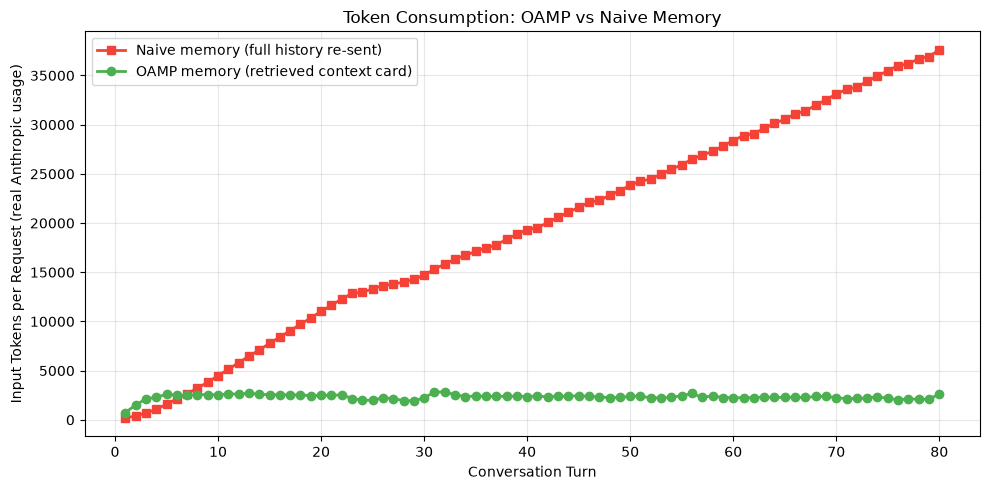


Turn     OAMP tokens    Naive tokens      Growth ratio
1                732             178              0.2x
2              1,516             402              0.3x
3              2,115             697              0.3x
4              2,319           1,052              0.5x
5              2,575           1,595              0.6x
6              2,519           2,128              0.8x
7              2,488           2,646              1.1x
8              2,567           3,227              1.3x
9              2,564           3,820              1.5x
10             2,532           4,485              1.8x
11             2,644           5,142              1.9x
12             2,608           5,807              2.2x
13             2,705           6,467              2.4x
14             2,606           7,105              2.7x
15             2,548           7,766              3.0x
16             2,554           8,410              3.3x
17             2,529           9,065              3.6x
18       

In [8]:
turns = list(range(1, len(oamp_token_history) + 1))

plt.figure(figsize=(10, 5))
plt.plot(turns, naive_token_history, marker="s", color="#F44336",
         label="Naive memory (full history re-sent)", linewidth=2)
plt.plot(turns, oamp_token_history, marker="o", color="#4CAF50",
         label="OAMP memory (retrieved context card)", linewidth=2)
plt.xlabel("Conversation Turn")
plt.ylabel("Input Tokens per Request (real Anthropic usage)")
plt.title("Token Consumption: OAMP vs Naive Memory")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

total_naive = sum(naive_token_history)
total_oamp = sum(oamp_token_history)
savings = (1 - total_oamp / total_naive) * 100 if total_naive else 0.0

print("\n" + "=" * 60)
print(f"{'Turn':<6}{'OAMP tokens':>14}{'Naive tokens':>16}{'Growth ratio':>18}")
print("=" * 60)
for t, o, n in zip(turns, oamp_token_history, naive_token_history):
    ratio = n / o if o else float("inf")
    print(f"{t:<6}{o:>14,}{n:>16,}{ratio:>17.1f}x")
print("=" * 60)
print(f"{'TOTAL':<6}{total_oamp:>14,}{total_naive:>16,}")
print(f"\nOAMP sent {savings:.1f}% fewer input tokens across the conversation.")
if oamp_token_history and oamp_token_history[-1]:
    print(f"By turn {turns[-1]}, the naive agent sends {naive_token_history[-1] / oamp_token_history[-1]:.1f}x "
          f"more tokens per request than the OAMP agent.")

> **💡 Key takeaway — memory is a token-economics decision.** Naive memory's cumulative cost grows with *conversation length²* (each turn is longer **and** there are more of them). OAMP converts that into a flat, predictable per-turn cost by retrieving a small context card instead of replaying history. Over a long-running or high-volume agent, that's the difference between a sustainable bill and a runaway one.

---
## Benchmark 2 — Latency

Two clocks per turn: **memory-layer latency** (work *before* the model call — appending to a list vs. persisting + extracting + retrieving) and **end-to-end latency** (the whole turn). The y-axes are **log scale** so one slow turn doesn't flatten the rest — read the **p50/p95** rows for the typical case.

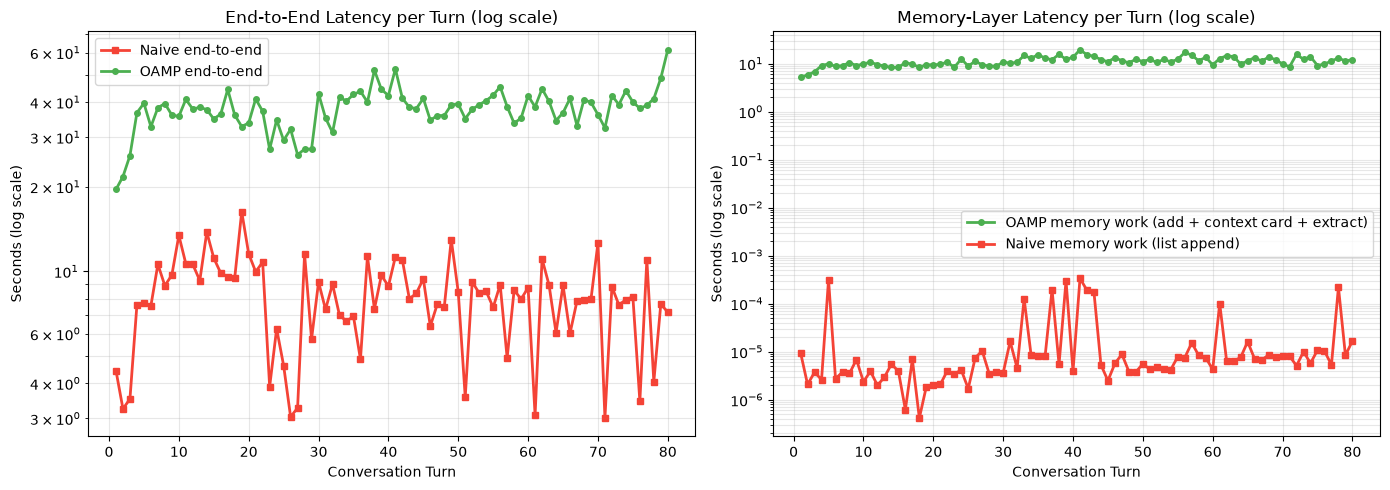


Metric                                mean         p50         p95         max       where
OAMP end-to-end (s)                 37.90s      38.34s      45.53s      61.41s     turn 80
Naive end-to-end (s)                 8.15s       8.23s      12.63s      16.31s     turn 19
OAMP memory work (s)                11.25s      10.95s      15.40s      19.38s     turn 41
Naive memory work (s)                0.00s       0.00s       0.00s       0.00s     turn 41

Anthropic prompt caching on the naive agent: 1,511,862 input tokens served from cache (97% of all naive input tokens).
Those cached tokens cost ~0.1x and add ~no prefill latency - which is why re-sending the whole
history stays cheap on wall-clock time even as the token count grows.


In [9]:
import numpy as np

turns = list(range(1, len(oamp_total_latency) + 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(turns, naive_total_latency, marker="s", color="#F44336", label="Naive end-to-end", linewidth=2, markersize=4)
ax1.plot(turns, oamp_total_latency, marker="o", color="#4CAF50", label="OAMP end-to-end", linewidth=2, markersize=4)
ax1.set_xlabel("Conversation Turn"); ax1.set_ylabel("Seconds (log scale)")
ax1.set_title("End-to-End Latency per Turn (log scale)")
ax1.set_yscale("log"); ax1.grid(True, alpha=0.3, which="both"); ax1.legend()

ax2.plot(turns, oamp_retrieval_latency, marker="o", color="#4CAF50",
         label="OAMP memory work (add + context card + extract)", linewidth=2, markersize=4)
ax2.plot(turns, naive_retrieval_latency, marker="s", color="#F44336",
         label="Naive memory work (list append)", linewidth=2, markersize=4)
ax2.set_xlabel("Conversation Turn"); ax2.set_ylabel("Seconds (log scale)")
ax2.set_title("Memory-Layer Latency per Turn (log scale)")
ax2.set_yscale("log"); ax2.grid(True, alpha=0.3, which="both"); ax2.legend()

plt.tight_layout(); plt.show()


def _pcts(arr):
    a = np.asarray(arr, dtype=float)
    return float(np.mean(a)), float(np.median(a)), float(np.percentile(a, 95)), float(np.max(a))


print("\n" + "=" * 90)
print(f"{'Metric':<30}{'mean':>12}{'p50':>12}{'p95':>12}{'max':>12}{'where':>12}")
print("=" * 90)
for label, arr in [
    ("OAMP end-to-end (s)", oamp_total_latency),
    ("Naive end-to-end (s)", naive_total_latency),
    ("OAMP memory work (s)", oamp_retrieval_latency),
    ("Naive memory work (s)", naive_retrieval_latency),
]:
    mean, p50, p95, mx = _pcts(arr); where = int(np.argmax(arr)) + 1
    print(f"{label:<30}{mean:>11.2f}s{p50:>11.2f}s{p95:>11.2f}s{mx:>11.2f}s{('turn ' + str(where)):>12}")
print("=" * 90)

total_naive_cache = sum(naive_cache_read)
denom = max(sum(naive_token_history), 1)
print(f"\nAnthropic prompt caching on the naive agent: {total_naive_cache:,} input tokens served from cache "
      f"({total_naive_cache / denom * 100:.0f}% of all naive input tokens).")
print("Those cached tokens cost ~0.1x and add ~no prefill latency - which is why re-sending the whole")
print("history stays cheap on wall-clock time even as the token count grows.")

> **Why doesn't the naive agent's latency climb with its token count?**
>
> Because of **Anthropic prompt caching**. The naive agent's `messages` list is append-only — every turn begins with the *exact same bytes* as the previous turn, then adds a tail. We mark that prefix with `cache_control`, so Anthropic stores it and, on the next turn, **re-reads the unchanged prefix from cache** at ~0.1× cost and near-zero prefill time. End-to-end latency is then dominated by **output decoding** (≈50–150 tokens for a 1–3 sentence answer), which doesn't grow — so the line stays roughly flat even as the prompt balloons to tens of thousands of tokens. The token *meter* keeps running (Benchmark 1); the latency *clock* barely moves.
>
> **OAMP's basic agent pays its latency elsewhere:** each turn does a DB write, a vector retrieval, and — every few turns — an **LLM extraction call** to mine new memories. That memory work is the green line in the right-hand chart. It buys durable, cross-session memory and a tiny prompt; the price is extra round-trips on the critical path. Benchmark 4 shows how to win that latency back.

> **💡 Key takeaway — "fewer tokens" does not automatically mean "faster".** With prompt caching, re-sending a big history is cheap on *latency* (though not on *tokens*). OAMP's basic pattern trades a little latency (extraction round-trips) for durable memory and a small prompt. Know which resource you're actually optimising — tokens, latency, or durability — because they don't all move together.

---
## Benchmark 3 — Response Quality via LLM-as-a-Judge

Saving tokens is worthless if answers get worse. For each turn we show **both** answers to an impartial judge (`claude-opus-4-8`) and ask it to pick the better one on accuracy, completeness, relevance, and coherence.

> **A caveat worth stating:** within a *single* session the naive agent holds the entire verbatim transcript, so it has perfect recall — it *should* do well here. OAMP's advantage is **durability and scale** (memory that survives across sessions and doesn't grow the prompt), not within-session recall. A close score with far fewer tokens is the real win. (Note too that the judge is the same model family as the agents — a known LLM-as-judge bias; in production use a different judge model or a human panel.)

In [ ]:
JUDGE_PROMPT = """You are an impartial judge evaluating two AI assistant responses to a user query.

**User query:**
{query}

**Response A:**
{response_a}

**Response B:**
{response_b}

Evaluate both responses on:
1. Accuracy - factual correctness against the query and any context mentioned earlier
2. Completeness - does it fully address what was asked
3. Relevance - on-topic and appropriately detailed
4. Coherence - well-structured and clear

Return EXACTLY this JSON object and nothing else:
{{"winner": "A" or "B" or "Tie", "reason": "one short sentence explanation"}}"""


def _extract_json(raw: str) -> dict:
    """Robustly pull a JSON object out of a model response (tolerates code fences / prose)."""
    raw = raw.strip()
    if raw.startswith("```"):
        raw = raw.strip("`")
        raw = re.sub(r"^json\s*", "", raw, flags=re.IGNORECASE).strip()
    try:
        return _json_lib.loads(raw)
    except Exception:
        m = re.search(r"\{.*\}", raw, re.DOTALL)
        if m:
            try:
                return _json_lib.loads(m.group(0))
            except Exception:
                pass
    return {"winner": "Tie", "reason": f"(judge parse error: {raw[:80]})"}


def judge_turn(query: str, response_a: str, response_b: str) -> dict:
    text, _ = call_claude(
        [{"role": "user", "content": JUDGE_PROMPT.format(query=query, response_a=response_a, response_b=response_b)}],
        system="You are an impartial evaluation judge. Output only the requested JSON object.",
        max_tokens=200,
    )
    return _extract_json(text)


judgments = []
judged_turns = RUN_TURNS[:len(oamp_responses)]
print(f"Judging {len(judged_turns)} turn-pairs with {AGENT_MODEL} as the judge...\n")
for i, (q, a, b) in enumerate(zip(judged_turns, oamp_responses, naive_responses), 1):
    verdict = judge_turn(q, a, b)
    verdict["query"] = q
    judgments.append(verdict)
    label = {"A": "OAMP ", "B": "Naive", "Tie": "Tie  "}.get(verdict.get("winner"), str(verdict.get("winner")))
    print(f"Turn {i:2d}: winner={label}  {str(verdict.get('reason', ''))[:100]}")

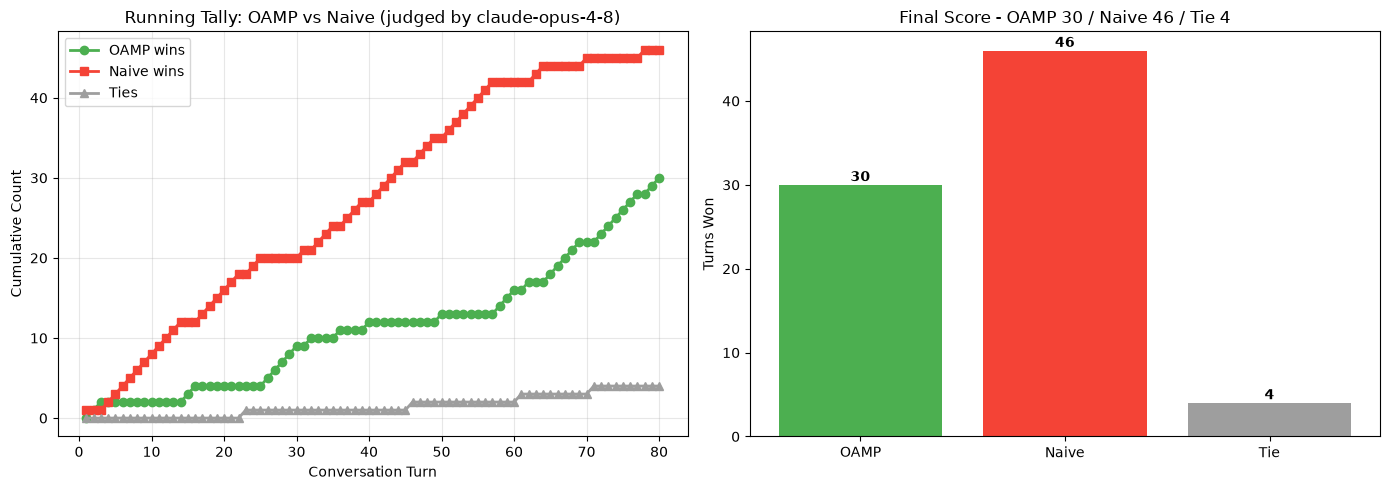


=== Final tally over 80 turns ===
  OAMP  wins:  30 ( 37.5%)
  Naive wins:  46 ( 57.5%)
  Ties:         4 (  5.0%)


In [11]:
wins = {"OAMP": 0, "Naive": 0, "Tie": 0}
oamp_running, naive_running, tie_running = [], [], []
for j in judgments:
    if j.get("winner") == "A": wins["OAMP"] += 1
    elif j.get("winner") == "B": wins["Naive"] += 1
    else: wins["Tie"] += 1
    oamp_running.append(wins["OAMP"]); naive_running.append(wins["Naive"]); tie_running.append(wins["Tie"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
turns = list(range(1, len(judgments) + 1))
ax1.plot(turns, oamp_running, marker="o", color="#4CAF50", label="OAMP wins", linewidth=2)
ax1.plot(turns, naive_running, marker="s", color="#F44336", label="Naive wins", linewidth=2)
ax1.plot(turns, tie_running, marker="^", color="#9E9E9E", label="Ties", linewidth=2)
ax1.set_xlabel("Conversation Turn"); ax1.set_ylabel("Cumulative Count")
ax1.set_title(f"Running Tally: OAMP vs Naive (judged by {AGENT_MODEL})")
ax1.grid(True, alpha=0.3); ax1.legend()

colors = {"OAMP": "#4CAF50", "Naive": "#F44336", "Tie": "#9E9E9E"}
bars = ax2.bar(list(wins.keys()), list(wins.values()), color=[colors[k] for k in wins])
ax2.set_ylabel("Turns Won")
ax2.set_title(f"Final Score - OAMP {wins['OAMP']} / Naive {wins['Naive']} / Tie {wins['Tie']}")
for bar, count in zip(bars, wins.values()):
    if count > 0:
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05, str(count),
                 ha="center", va="bottom", fontweight="bold")
plt.tight_layout(); plt.show()

total = len(judgments) or 1
print(f"\n=== Final tally over {len(judgments)} turns ===")
print(f"  OAMP  wins: {wins['OAMP']:3d} ({wins['OAMP'] / total * 100:5.1f}%)")
print(f"  Naive wins: {wins['Naive']:3d} ({wins['Naive'] / total * 100:5.1f}%)")
print(f"  Ties:       {wins['Tie']:3d} ({wins['Tie'] / total * 100:5.1f}%)")

> **💡 Key takeaway — measure quality, don't assume it.** A smaller prompt is only a good deal if quality holds. OAMP retrieves the *relevant* facts rather than dumping everything, and an LLM judge lets you quantify whether that retrieval is good enough for your task. Always pair an efficiency change with a quality check.

---
## Benchmark 4 — A Cache-Friendly OAMP Agent

So far: **naive** = low latency (caching) but high tokens; **OAMP basic** = low tokens but extra latency. Can we get **durable memory *and* low latency *and* prompt caching** all at once?

Almost. This third agent combines four ideas:
1. **Append-only history** — so the prompt prefix is byte-stable and prompt caching stays warm.
2. **A short retrieved memory tail** appended to the latest turn — durable hints from prior sessions.
3. **Durable write-behind** to OAMP — a fast DB write, with **no LLM extraction on the critical path** (deferred to a batch job; see Strategy 6).
4. **Periodic compaction** with the small model — to stop the cached prefix growing forever.

The catch: this pattern **gives back the token savings**. You can have any **two** of {low tokens, low latency, durable memory} cleanly — getting all three means accepting token growth. That is the central trade-off of agent memory.

In [12]:
cached_connection = oracledb.connect(
    user=os.environ["DB_USER"], password=os.environ["DB_PASSWORD"], dsn=os.environ["DB_CONNECT_STRING"],
)

# No LLM attached -> no automatic, on-the-critical-path memory extraction.
cached_client = OracleAgentMemory(
    connection=cached_connection,
    embedder=embedder,
    extract_memories=False,
    schema_policy="recreate",                # PRISTINE RUN: drop & recreate the oamp_bench_cached tables on every execution
    table_name_prefix="oamp_bench_cached",
)

CACHED_USER = "benchmark-user-cached"
CACHED_AGENT = "benchmark-agent-cached"
for fn, eid, info in [
    (cached_client.add_user, CACHED_USER, "Richmond - cache-friendly benchmark."),
    (cached_client.add_agent, CACHED_AGENT, "Cache-friendly OAMP-backed assistant."),
]:
    try:
        fn(eid, info)
    except ValueError as exc:
        if "already exists" not in str(exc):
            raise

cached_thread = cached_client.create_thread(user_id=CACHED_USER, agent_id=CACHED_AGENT)

cached_token_history, cached_cache_read = [], []
cached_retrieval_latency, cached_total_latency = [], []
cached_responses = []

# Append-only history -> byte-stable prefix every turn -> prompt cache stays warm.
cached_messages = []

COMPACTION_INTERVAL = 20   # every N turns, condense older messages with the small model
KEEP_RECENT_TURNS = 4      # keep this many recent user/assistant pairs verbatim


def call_oamp_cached_agent(user_query: str) -> str:
    """Cache-friendly OAMP agent - full history (prompt-cached) + a short retrieved memory tail,
    with durable write-behind to OAMP (a fast DB write, no LLM on the critical path)."""
    t_start = time.perf_counter()

    t_retrieve_start = time.perf_counter()
    hits = cached_client.search(user_query, user_id=CACHED_USER, agent_id=CACHED_AGENT,
                                max_results=3, record_types=["memory"])
    hint = ("\n\n[Memory hints from prior sessions:\n" + "\n".join(f"- {h.content}" for h in hits) + "]") if hits else ""
    t_retrieve_end = time.perf_counter()

    cached_messages.append({"role": "user", "content": user_query + hint})
    answer, usage = call_claude(cached_messages, cache=True)
    cached_messages.append({"role": "assistant", "content": answer})

    cached_thread.add_messages([                                  # durable write-behind (fast DB write, no LLM)
        Message(role="user", content=user_query),
        Message(role="assistant", content=answer),
    ])

    t_end = time.perf_counter()
    cached_token_history.append(prompt_tokens(usage))
    cached_cache_read.append(getattr(usage, "cache_read_input_tokens", 0))
    cached_retrieval_latency.append(t_retrieve_end - t_retrieve_start)
    cached_total_latency.append(t_end - t_start)
    cached_responses.append(answer)
    return answer


def compact_older_messages(turn_number: int) -> bool:
    """Every COMPACTION_INTERVAL turns, replace older messages with a small-model summary.
    Keeps the in-memory prefix bounded so token growth is sawtooth instead of linear,
    at the cost of one cache reset at each compaction boundary. (Claude has no 'system'
    role inside messages, so we represent the summary as a user/assistant pair.)"""
    if turn_number == 0 or turn_number % COMPACTION_INTERVAL != 0:
        return False
    keep = 2 * KEEP_RECENT_TURNS
    if len(cached_messages) <= keep + 2:
        return False
    older, recent = cached_messages[:-keep], cached_messages[-keep:]
    transcript = "\n".join(f"[{m['role']}] {m['content']}" for m in older)
    summary_text, _ = call_claude(
        [{"role": "user", "content": (
            "Condense this conversation history into a concise summary. Preserve ALL named "
            "entities, numbers, dates, decisions, tool/method names, patient identifiers, and "
            "personnel changes. Aim for ~30-40% of the original length.\n\n"
            f"Transcript:\n{transcript}")}],
        system="You faithfully compress conversation history without losing facts.",
        model=SMALL_MODEL, max_tokens=1024,
    )
    cached_messages[:] = (
        [{"role": "user", "content": f"[Earlier conversation summary through turn {turn_number - KEEP_RECENT_TURNS}]\n{summary_text}"},
         {"role": "assistant", "content": "Understood - I have the earlier context."}]
        + recent
    )
    return True


print("Cache-friendly OAMP agent ready.")
print(f"Compaction every {COMPACTION_INTERVAL} turns, keeping the last {KEEP_RECENT_TURNS} turns verbatim.")

Cache-friendly OAMP agent ready.
Compaction every 20 turns, keeping the last 4 turns verbatim.


### Why this design

- **Append-only + `cache_control`** → Anthropic re-reads the stable prefix from cache, so prefill stays cheap (low latency, like the naive agent).
- **No inline extraction** → the expensive LLM memory-mining is removed from the user-facing path; we run it **once, offline**, at the end (Strategy 6).
- **`cached_client.add_messages(...)`** is a plain DB write — durable persistence with no model round-trip.
- **Compaction** every `COMPACTION_INTERVAL` turns swaps older messages for a small-model summary, bounding the prefix (token growth becomes sawtooth, not linear) — at the cost of one cache reset per compaction.

### Run the same turns through the cache-friendly agent

We reuse `RUN_TURNS`. The answers and token counts will look much like the naive agent's — the difference is in *where* the work happens (cheap DB writes instead of inline extraction) and in the latency profile.

In [ ]:
print(f"Running {len(RUN_TURNS)} turns through the cache-friendly OAMP agent...\n")
for i, q in enumerate(RUN_TURNS, 1):
    print(f"=== Turn {i:2d}/{len(RUN_TURNS)} ===")
    print(f"USER: {q[:140]}{'...' if len(q) > 140 else ''}")
    answer = call_oamp_cached_agent(q)
    print(f"  [Cached, {cached_token_history[-1]:>6} tok, {cached_total_latency[-1]:5.1f}s] {answer[:140]}")
    if i % COMPACTION_INTERVAL == 0:
        before = len(cached_messages)
        if compact_older_messages(i):
            print(f"  [Compacted at turn {i}: {before} -> {len(cached_messages)} messages - cache resets here]")
    print()

### Compare all three patterns on tokens

The cache-friendly agent grows like the naive agent (it sends the full history); OAMP basic stays flat. This is the trade we deliberately made: accept token growth to recover prompt caching and remove extraction latency.

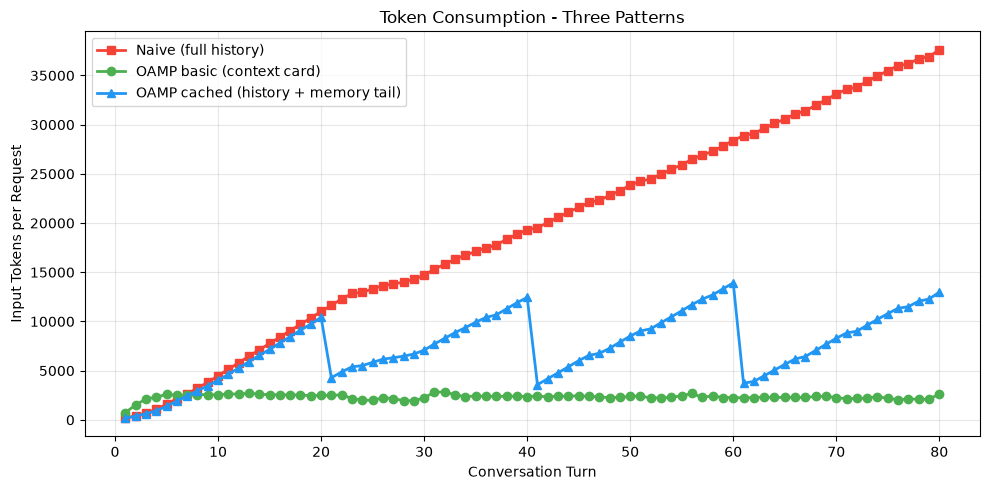


Final-turn input tokens:
  Naive:       37,615
  OAMP basic:   2,643
  OAMP cached: 12,970


In [14]:
turns = list(range(1, len(cached_total_latency) + 1))
n = len(turns)

plt.figure(figsize=(10, 5))
plt.plot(turns, naive_token_history[:n], marker="s", color="#F44336", linewidth=2, label="Naive (full history)")
plt.plot(turns, oamp_token_history[:n], marker="o", color="#4CAF50", linewidth=2, label="OAMP basic (context card)")
plt.plot(turns, cached_token_history, marker="^", color="#2196F3", linewidth=2, label="OAMP cached (history + memory tail)")
plt.xlabel("Conversation Turn"); plt.ylabel("Input Tokens per Request")
plt.title("Token Consumption - Three Patterns"); plt.grid(True, alpha=0.3); plt.legend()
plt.tight_layout(); plt.show()

print("\nFinal-turn input tokens:")
print(f"  Naive:       {naive_token_history[n - 1]:>6,}")
print(f"  OAMP basic:  {oamp_token_history[n - 1]:>6,}")
print(f"  OAMP cached: {cached_token_history[-1]:>6,}")

> **"OAMP cached and naive look almost identical on tokens — so what did OAMP buy me?"**
>
> Durability and a clean retrieval surface. The token *reduction* was the **basic OAMP** pattern's win; the cache-friendly pattern gives it back to recover caching and remove inline extraction. What you keep is **persistent, queryable memory** in Oracle AI Database — every turn durably stored, every extracted fact searchable in *future* sessions, which a pure in-memory naive agent simply cannot do. You can have any two of {low tokens, low latency, durable memory} in one agent — pick the two your workload needs.

### Compare all three patterns on latency

This is the headline chart. The cache-friendly agent should track the naive agent closely on end-to-end latency (both benefit from prompt caching and neither does inline extraction). The basic OAMP agent's extra LLM round-trips are the gap.

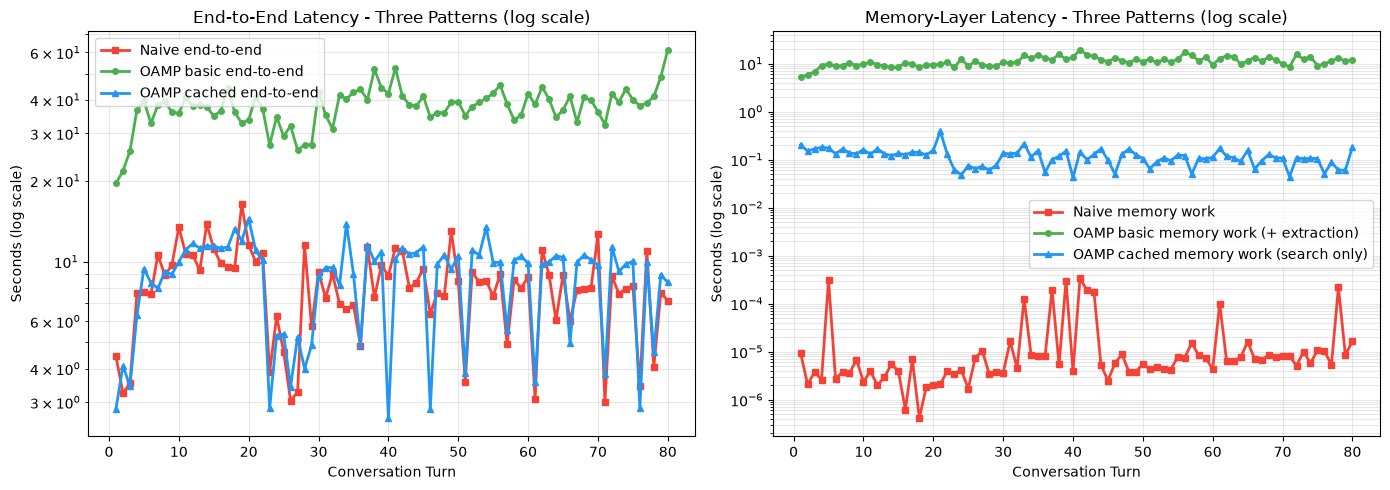


Metric                             pattern      mean       p50       p95       max      max@turn
End-to-end per turn (s)              Naive     8.15s     8.23s    12.63s    16.31s       turn 19
End-to-end per turn (s)         OAMP basic    37.90s    38.34s    45.53s    61.41s       turn 80
End-to-end per turn (s)        OAMP cached     8.76s     9.89s    12.02s    14.44s       turn 20
Memory work per turn (s)             Naive     0.00s     0.00s     0.00s     0.00s       turn 41
Memory work per turn (s)        OAMP basic    11.25s    10.95s    15.40s    19.38s       turn 41
Memory work per turn (s)       OAMP cached     0.12s     0.12s     0.18s     0.39s       turn 21

Total wall-clock across the conversation:
  Naive:         652.4s
  OAMP basic:   3032.1s
  OAMP cached:   700.8s


In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
n = len(turns)

ax1.plot(turns, naive_total_latency[:n], marker="s", color="#F44336", linewidth=2, markersize=4, label="Naive end-to-end")
ax1.plot(turns, oamp_total_latency[:n], marker="o", color="#4CAF50", linewidth=2, markersize=4, label="OAMP basic end-to-end")
ax1.plot(turns, cached_total_latency, marker="^", color="#2196F3", linewidth=2, markersize=4, label="OAMP cached end-to-end")
ax1.set_xlabel("Conversation Turn"); ax1.set_ylabel("Seconds (log scale)")
ax1.set_title("End-to-End Latency - Three Patterns (log scale)")
ax1.set_yscale("log"); ax1.grid(True, alpha=0.3, which="both"); ax1.legend()

ax2.plot(turns, naive_retrieval_latency[:n], marker="s", color="#F44336", linewidth=2, markersize=4, label="Naive memory work")
ax2.plot(turns, oamp_retrieval_latency[:n], marker="o", color="#4CAF50", linewidth=2, markersize=4, label="OAMP basic memory work (+ extraction)")
ax2.plot(turns, cached_retrieval_latency, marker="^", color="#2196F3", linewidth=2, markersize=4, label="OAMP cached memory work (search only)")
ax2.set_xlabel("Conversation Turn"); ax2.set_ylabel("Seconds (log scale)")
ax2.set_title("Memory-Layer Latency - Three Patterns (log scale)")
ax2.set_yscale("log"); ax2.grid(True, alpha=0.3, which="both"); ax2.legend()
plt.tight_layout(); plt.show()


def _stats(arr):
    a = np.asarray(arr, dtype=float)
    return float(np.mean(a)), float(np.median(a)), float(np.percentile(a, 95)), float(np.max(a)), int(np.argmax(a)) + 1


print("\n" + "=" * 104)
print(f"{'Metric':<28}{'pattern':>14}{'mean':>10}{'p50':>10}{'p95':>10}{'max':>10}{'max@turn':>14}")
print("=" * 104)
for label, pattern, arr in [
    ("End-to-end per turn (s)", "Naive", naive_total_latency[:n]),
    ("End-to-end per turn (s)", "OAMP basic", oamp_total_latency[:n]),
    ("End-to-end per turn (s)", "OAMP cached", cached_total_latency),
    ("Memory work per turn (s)", "Naive", naive_retrieval_latency[:n]),
    ("Memory work per turn (s)", "OAMP basic", oamp_retrieval_latency[:n]),
    ("Memory work per turn (s)", "OAMP cached", cached_retrieval_latency),
]:
    mean, p50, p95, mx, where = _stats(arr)
    print(f"{label:<28}{pattern:>14}{mean:>9.2f}s{p50:>9.2f}s{p95:>9.2f}s{mx:>9.2f}s{('turn ' + str(where)):>14}")
print("=" * 104)
print("\nTotal wall-clock across the conversation:")
print(f"  Naive:       {sum(naive_total_latency[:n]):>7.1f}s")
print(f"  OAMP basic:  {sum(oamp_total_latency[:n]):>7.1f}s")
print(f"  OAMP cached: {sum(cached_total_latency):>7.1f}s")

> **Reading these charts.** The y-axes are **log scale** so a single slow turn (network blip, a compaction call, a cold cache) doesn't squash every other point into a flat line. Trust the **p50** and **p95** rows in the table for the typical-case story; **mean** and **total** are sensitive to one-off tail-latency spikes.

### Strategy 6 — offline batch extraction

The cache-friendly agent never extracted memories on the user's clock. Now that nobody is waiting, we mine the **entire** persisted transcript in **one** call with the **small model** (`claude-haiku-4-5`). In production this runs in a background worker, a queue consumer, or a nightly cron — never on the request path. The extracted facts become searchable OAMP memories for every future session.

In [16]:
print("Running offline batch extraction with the small model...")
t_extract_start = time.perf_counter()

all_messages = cached_thread.get_messages()
transcript = "\n".join(f"[{m.role}] {m.content}" for m in all_messages)

extract_prompt = (
    "Extract the most important durable, atomic facts from this conversation that would be "
    "useful for future sessions. Each fact should be self-contained and independently meaningful. "
    "Return at most the 25 most important facts.\n\n"
    f"Conversation transcript:\n{transcript}\n\n"
    'Return JSON with this exact shape: {"facts": ["fact 1", "fact 2", ...]}'
)

# A small-but-not-tiny cap on the fact list keeps the JSON from truncating on long
# transcripts (which would fail to parse); 4096 output tokens is ample for ~25 facts.
raw, _ = call_claude(
    [{"role": "user", "content": extract_prompt}],
    system="You extract durable facts and output only the requested JSON.",
    model=SMALL_MODEL, max_tokens=4096,
)
parsed = _extract_json(raw)
facts = parsed.get("facts", []) if isinstance(parsed, dict) else []

for fact in facts:
    cached_client.add_memory(fact, user_id=CACHED_USER, agent_id=CACHED_AGENT, thread_id=cached_thread.thread_id)

t_extract_end = time.perf_counter()
print(f"\nExtracted {len(facts)} durable facts in {t_extract_end - t_extract_start:.1f}s using {SMALL_MODEL}.")
print("All facts are now searchable via cached_client.search() in any future session.\n")
print("First 5 extracted facts:")
for f in facts[:5]:
    print(f"  - {f}")

Running offline batch extraction with the small model...

Extracted 39 durable facts in 35.2s using claude-haiku-4-5.
All facts are now searchable via cached_client.search() in any future session.

First 5 extracted facts:
  - Dr. Mei Zhang (Johns Hopkins) is a single-cell RNA-seq specialist leading the cell-type annotation arm, integrating scRNA-seq from 60 organoid lines with Sarah's ATAC-seq and Hi-C data to produce matched multi-modal embeddings.
  - Patient ND-2104: 6-year-old with Christianson syndrome features; pipeline flagged a 14 kb tandem repeat expansion in the SLC9A6 enhancer region, ~85 kb upstream of the gene body—the first proband identified by ChromAtlas-ND not already in OMIM.
  - New GPU pod: 32× NVIDIA H100s on OCI added to the existing 128× A100 cluster, reducing Enforcer fine-tuning per-epoch time from 72 hours to ~22 hours (~3.3× speedup).
  - Software stack pinning: Nextflow 24.10 (primary orchestrator), Snakemake 8.18 (legacy fallback), MLflow (experiment track

### Recommended production pattern

| Pattern | Tokens / turn | End-to-end latency | Cross-session memory | When to use |
|---|---|---|---|---|
| **Naive (full history)** | grows linearly | low (with caching) | ❌ in-memory only | Short chats; prototypes; when simplicity wins |
| **OAMP basic** | flat & small | higher (inline extraction) | ✅ durable | Long-running agents; tight token / context budgets |
| **OAMP cache-friendly + batch extraction** | grows (cached) | low | ✅ durable | High-volume production: low latency *and* durable memory, extraction moved offline |

**Rule of thumb:** start naive, move to **OAMP basic** when prompt size or cost becomes the constraint, and adopt the **cache-friendly + offline-extraction** hybrid when you need low latency *and* durable memory at scale.

---
## 🎓 Key Takeaways

1. **Agent memory is a resource-allocation choice among three goods: low tokens, low latency, durable memory.** You can cleanly optimise any *two*. Naive memory buys low latency (caching) at the cost of tokens; OAMP basic buys low tokens and durability at the cost of latency; the cache-friendly hybrid buys low latency and durability by giving the tokens back.

2. **OAMP turns unbounded prompt growth into a flat, retrieved context card.** Instead of replaying the transcript, it persists each turn into Oracle AI Database, extracts durable facts, and retrieves only what's relevant — so per-turn token cost stays constant as the conversation grows.

3. **Anthropic prompt caching is explicit and observable.** Marking a stable prefix with `cache_control` makes re-sending history cheap on *latency* (≈0.1× cost, ~no prefill) — which is why naive latency stays flat even as its token meter climbs. You can read the effect directly in `usage.cache_read_input_tokens`.

4. **Match the model tier to the job — and put the boundary at the recall-critical path.** Frontier Claude (`claude-opus-4-8`) answers users, judges quality, **and does the *live* agent's memory extraction + summarisation**, because within a session those memories are the agent's only recall surface — a lossy extractor silently drops facts it will be graded on. The cheap tier (`claude-haiku-4-5`) is reserved for work that runs off the user's clock and off the recall path: compaction and offline batch extraction. "Mechanical-looking" is not the same as "safe to make cheap."

5. **Move expensive memory work off the critical path.** Inline extraction adds latency to every turn. A durable write-behind plus **offline batch extraction** gives you persistence now and rich memories later — without making the user wait.

6. **Durability is the thing a naive agent fundamentally cannot give you.** A growing `messages` list lives and dies with the process. OAMP memories survive in Oracle AI Database and are searchable across sessions, users, and agents — the foundation for agents that genuinely learn over time.

**Further reading:** [Oracle AI Agent Memory](https://www.oracle.com/database/ai-agent-memory/) · [OAMP API reference](https://docs.oracle.com/en/database/oracle/agent-memory/26.4/agmea/api/agentmemory.html)

## Cleanup

Delete the benchmark threads and close connections. The `oamp_bench*` tables stay in the schema so you can re-run without rebuilding them.

In [17]:
try:
    client.delete_thread(thread.thread_id)
except Exception as e:
    print(f"(basic OAMP cleanup skipped: {e})")
try:
    cached_client.delete_thread(cached_thread.thread_id)
    cached_connection.close()
except NameError:
    pass  # Benchmark 4 not run
except Exception as e:
    print(f"(cached OAMP cleanup skipped: {e})")
connection.close()
print("Benchmark resources cleaned up. (The oamp_bench* tables persist in the schema for re-runs.)")

Benchmark resources cleaned up. (The oamp_bench* tables persist in the schema for re-runs.)
